<a href="https://colab.research.google.com/github/MitchellAcoustics/SATP-Methodology/blob/dataset-checks/computation/dataset_checks/por_LNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checking the Soundscape Attributes Translation Project (SATP) Dataset


In [1]:
# Source - https://stackoverflow.com/a
# Posted by Sverrisson, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-24, License - CC BY-SA 4.0

import os

if os.getenv("COLAB_RELEASE_TAG"):
   print("Installing packages in Colab")
   ! uv pip install --system "soundscapy==0.8.0rc5"
else:
   print("NOT in Colab")


Installing packages in Colab
Using Python 3.12.12 environment at: /usr
Audited 1 package in 120ms


In [5]:
# Load in python packages
import soundscapy as sspy
from soundscapy.databases import isd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [7]:
# Import date class from datetime module
from datetime import date
# Returns the current local date
today = date.today()
print("Last working date: ", today)

version = "v1.5"
# satp_file = Path.cwd().parent.joinpath("DATASETS", f"SATP Dataset {version}.xlsx")
satp_file = Path('/content/SATP Dataset v1.5.xlsx')
version = "SATP" + version
print("Dataset version: ", version)

new_inst = 'LNC'
print("Checking new institution's data addition: ", new_inst)

Last working date:  2026-01-24
Dataset version:  SATPv1.5
Checking new institution's data addition:  LNC


### Load in our data and check data quality

In [11]:
VAL_RANGE = (100,0)

df = pd.read_excel(satp_file, sheet_name="Main Merge")
df, remove_df = isd.validate(df, val_range=VAL_RANGE)
df = sspy.surveys.add_iso_coords(df, val_range=VAL_RANGE)
df

,Language,Recording,Participant,Age,Gender,PAQ1,PAQ2,PAQ3,PAQ4,PAQ5,PAQ6,PAQ7,PAQ8,loud,Institution,sequence_id,ISOPleasant,ISOEventful
0,arb,CG01,BIS_1,55,NaN,57.0,23.0,68.0,7.0,17.0,7.0,16.0,75.0,NaN,BIS,NaN,0.411716,0.063087
1,arb,CG04,BIS_1,55,NaN,84.0,76.0,84.0,43.0,13.0,15.0,25.0,45.0,NaN,BIS,NaN,0.478614,0.417193
2,arb,CG07,BIS_1,55,NaN,14.0,15.0,74.0,66.0,56.0,73.0,23.0,15.0,NaN,BIS,NaN,-0.493223,0.190746
3,arb,CT301,BIS_1,55,NaN,5.0,14.0,14.0,94.0,85.0,94.0,75.0,4.0,NaN,BIS,NaN,-0.829289,-0.223381
4,arb,E01b,BIS_1,55,NaN,14.0,15.0,23.0,82.0,83.0,84.0,76.0,64.0,NaN,BIS,NaN,-0.540624,-0.368909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21054,zsm,KT01,UPM_59,29,Male,47.0,33.0,31.0,48.0,58.0,83.0,71.0,43.0,NaN,UPM,NaN,-0.206655,-0.297487
21055,zsm,E10,UPM_59,29,Male,42.0,30.0,83.0,66.0,58.0,41.0,19.0,34.0,NaN,UPM,NaN,-0.192218,0.326604
21056,zsm,W01,UPM_59,29,Male,15.0,86.0,70.0,92.0,87.0,44.0,35.0,4.0,NaN,UPM,NaN,-0.432965,0.525736
21057,zsm,E11b,UPM_59,29,Male,8.0,87.0,98.0,99.0,100.0,16.0,5.0,0.0,NaN,UPM,NaN,-0.463087,0.883137


### Check that the expected language is present and the number of recordings is correct

In [12]:
new_inst in df.Institution.unique()

True

In [13]:
len(df.Institution.unique())

23

In [14]:
len(df.Recording.unique()) == 27

True

In [15]:
len(df.query("Institution == @new_inst").Recording.unique()) == len(df.query("Institution != @new_inst").Recording.unique())

True

In [16]:
len(df.Participant.unique())

779

In [17]:
for part in df.Participant.unique():
    if len(df.query("Participant == @part").Recording.unique()) != 27:
        print(part)

BIS_27
SJZ_24
SJZ_T10
SJZ_T11
FUU_14
FUU_29
HAN_17
SHU_4
SHU_6
SHU_8
SHU_14
SHU_15
SHU_18
SHU_20
SHU_22
SHU_23
SHU_29
ANR_996


### Pull out a subset of sounds that we want to look at in more detail

In [18]:
df_sound = df.query("Recording in ['CG01', 'CG04', 'W06', 'W09']")
hue_order = ['CG01', 'CG04', 'W06', 'W09']


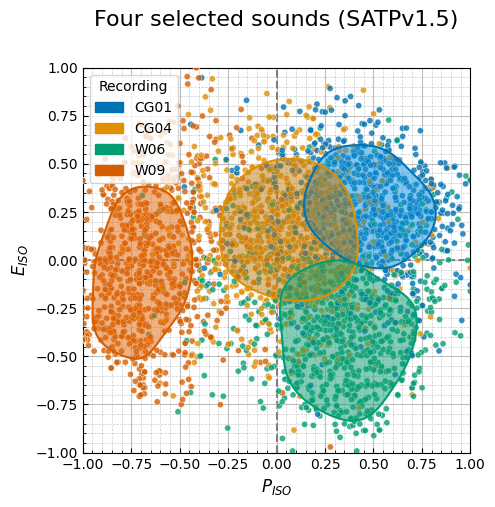

In [22]:
plot = sspy.density(
    df_sound,
    hue="Recording",
    title=f"Four selected sounds ({version})",
    density_type="simple",
    hue_order=hue_order,
    common_norm=False,
    legend='auto',
    incl_outline=True,
    incl_scatter=True,
)


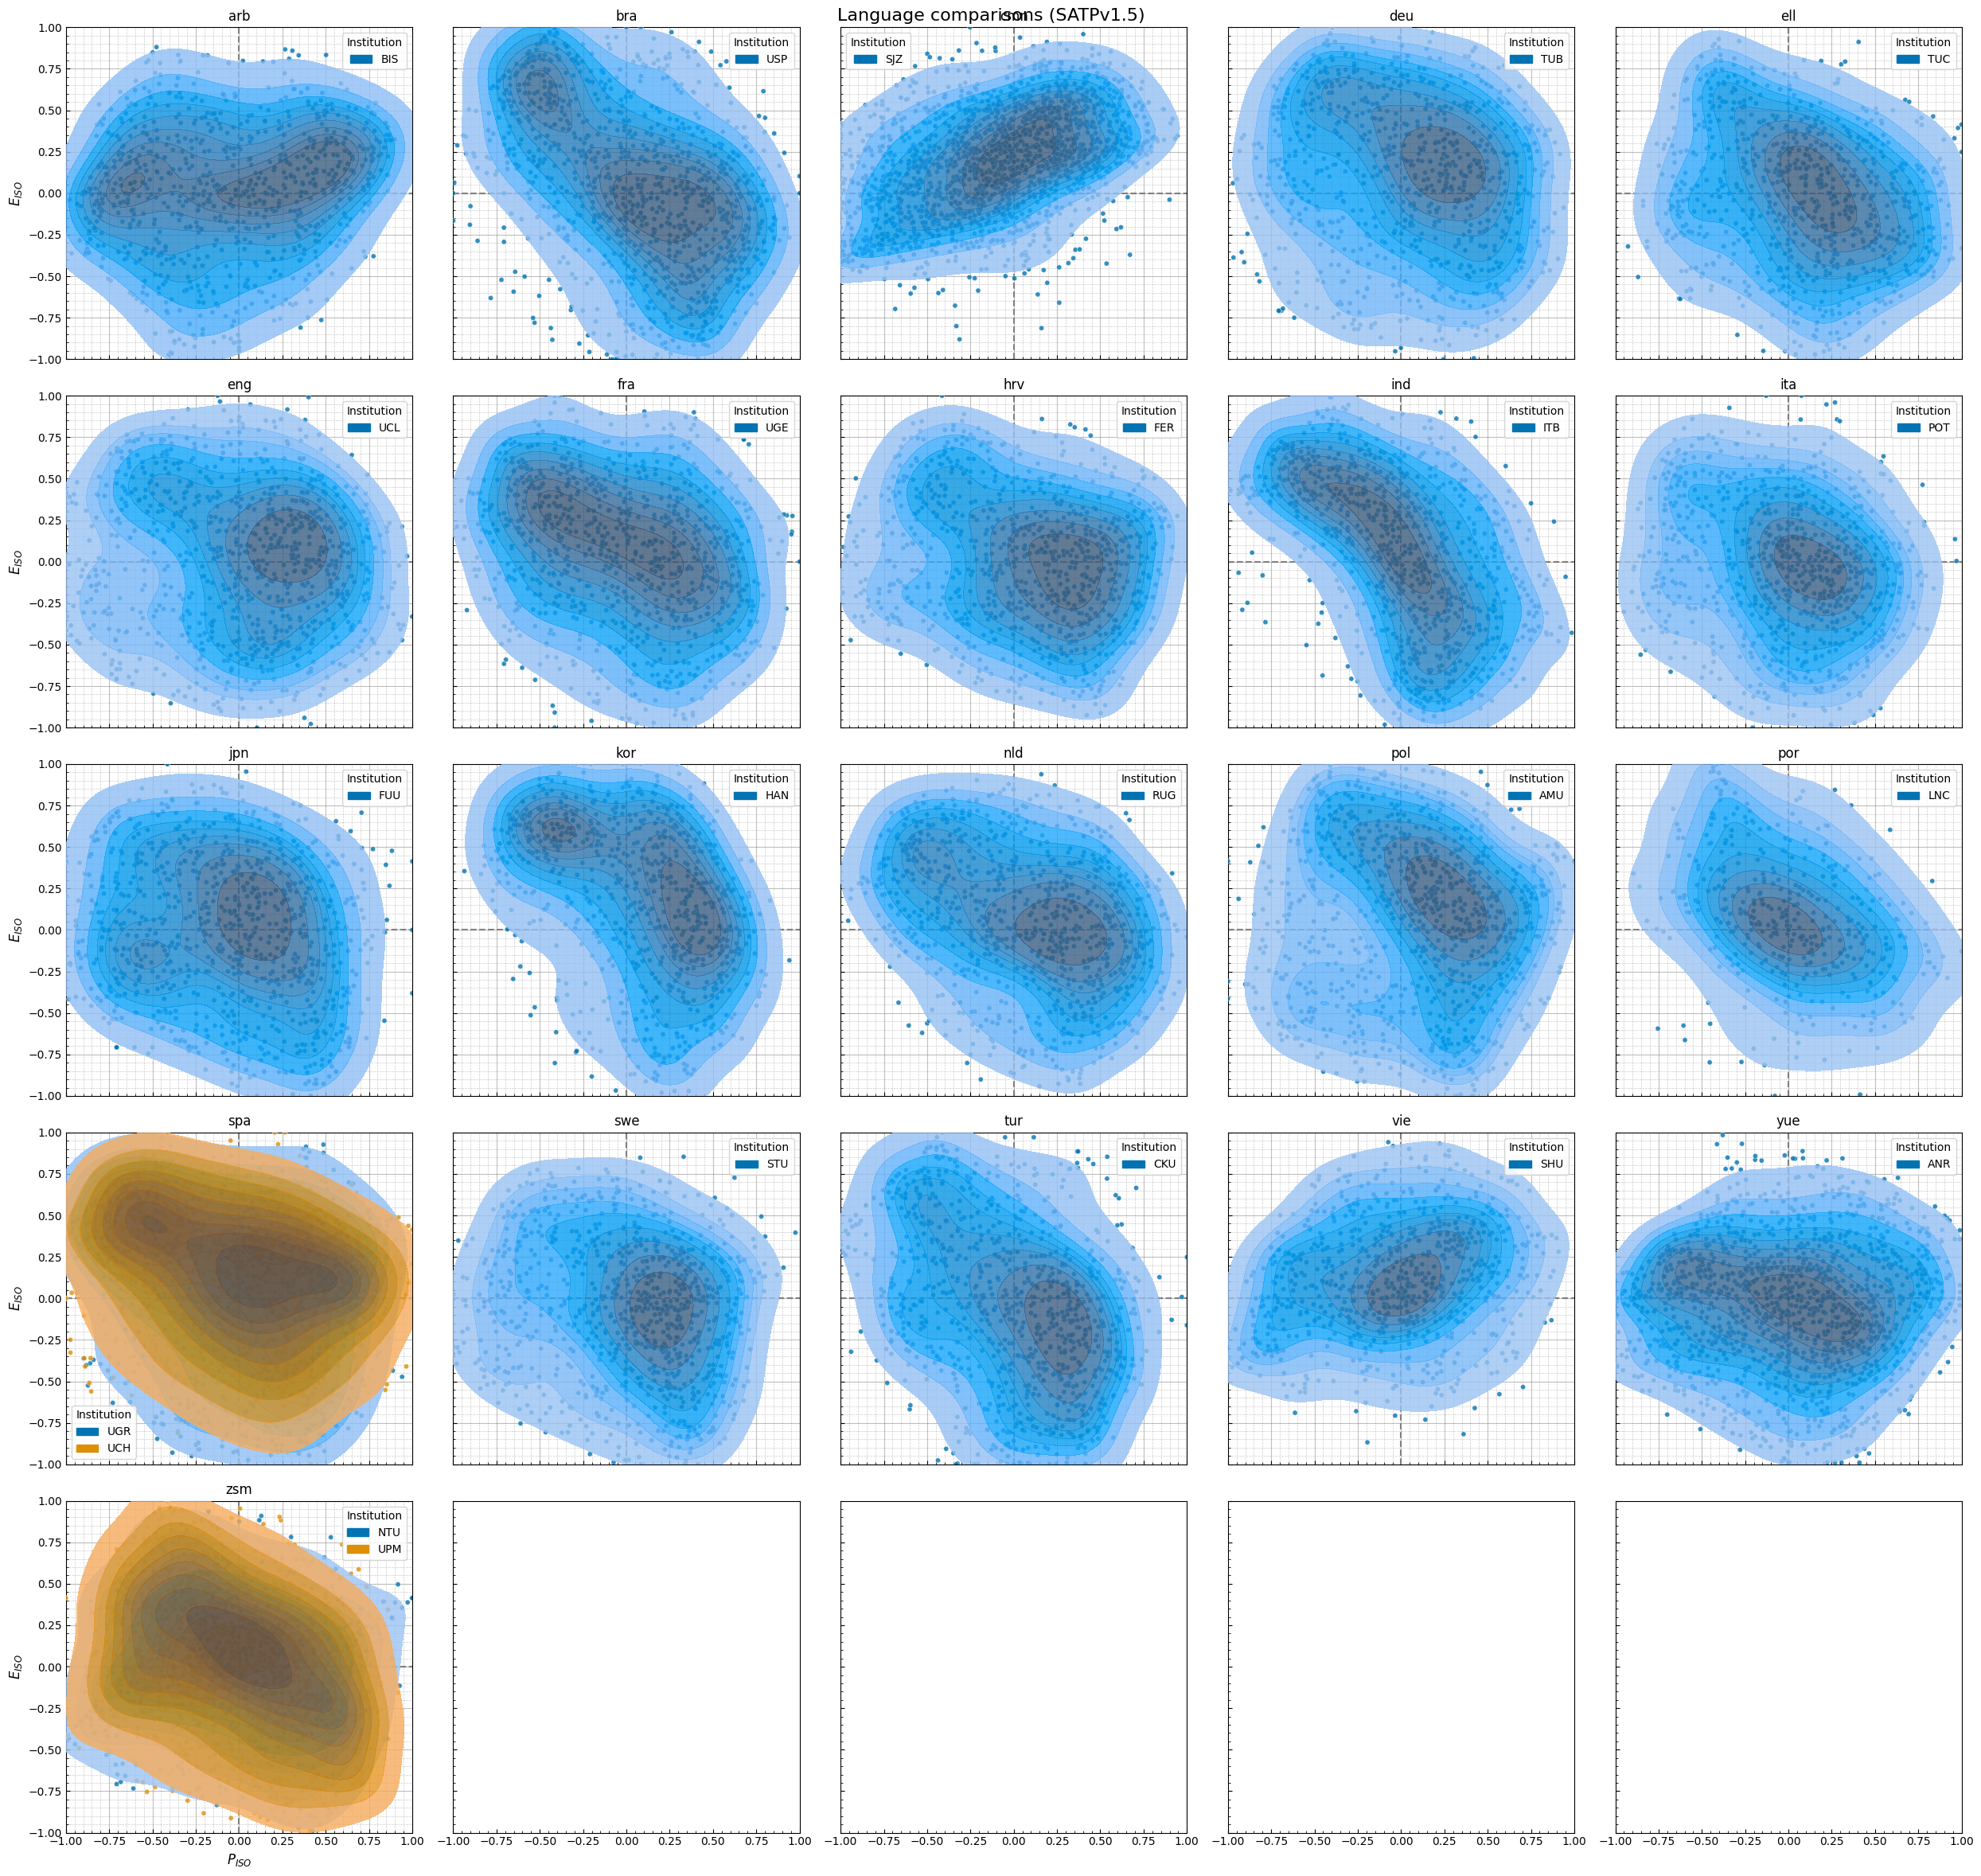

In [25]:
lang_plots = sspy.create_iso_subplots(
    df,
    title=f"Language comparisons ({version})",
    subplot_by = "Language",
    hue="Institution",
    subplot_size=(5,4)
)

## Summarise the general results across languages

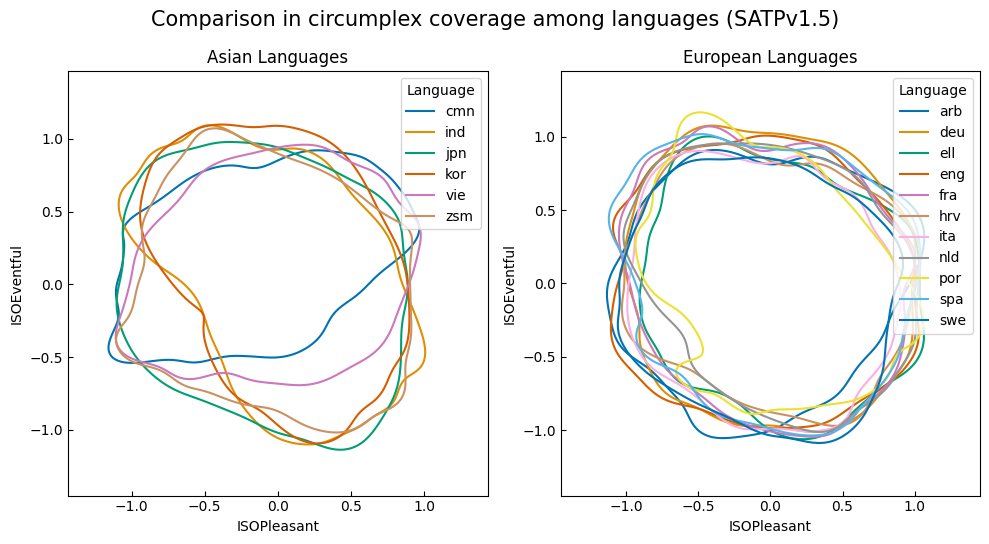

In [26]:
ASIAN_LANGS = ['cmn', 'ind', 'jpn', 'kor', 'vie', 'zsm']
EUR_LANGS = ['arb', 'ell', 'eng', 'fra', 'hrv', 'ita', 'nld', 'por', 'por', 'spa', 'deu', 'swe']

fig, axes = plt.subplots(1, 2, figsize=(10,5.5))
fig.suptitle(f"Comparison in circumplex coverage among languages ({version})", fontsize=15)

sns.kdeplot(data=df.query("Language in @ASIAN_LANGS"), x="ISOPleasant", y="ISOEventful", ax=axes.flatten()[0], levels=2, thresh=0.05, hue="Language", palette='colorblind', fill=False, common_norm=False)
axes.flatten()[0].set_title("Asian Languages")
sns.kdeplot(data=df.query("Language in @EUR_LANGS"), x="ISOPleasant", y="ISOEventful", ax=axes.flatten()[1], levels=2, thresh=0.05, hue="Language", palette='colorblind', fill=False, common_norm=False)
axes.flatten()[1].set_title("European Languages")
plt.tight_layout()

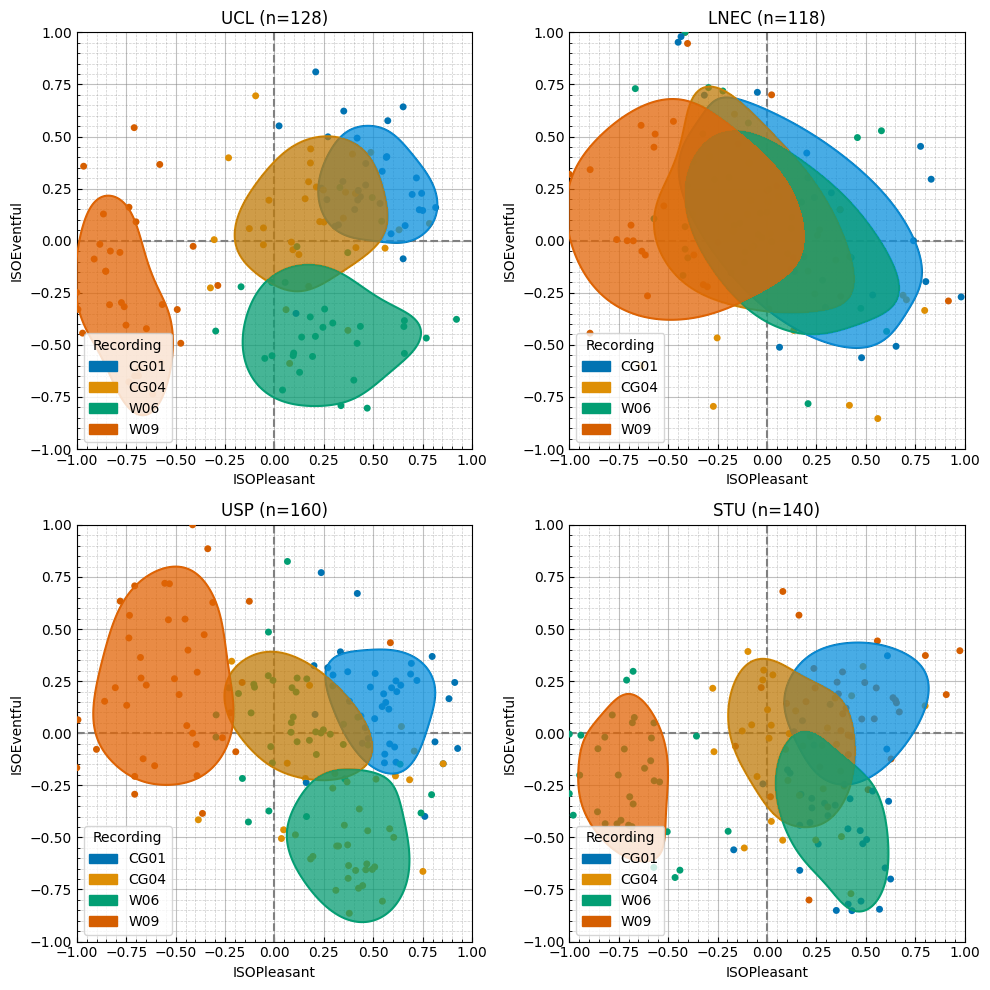

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))
hue_order = ['CG01', 'CG04', 'W06', 'W09']
for i, inst in enumerate(['UCL', new_inst, 'USP', 'STU']):
    lang = df_sound.query("Institution == @inst")
    sspy.plotting.density(lang, ax=axes.flatten()[i], title=f"{inst} (n={len(lang)})", hue="Recording", hue_order=hue_order, prim_labels=False, alpha=0.75, levels=2, thresh=0.5, palette='colorblind', legend=True, incl_outline=True, incl_scatter=True, common_norm=False)

plt.tight_layout()

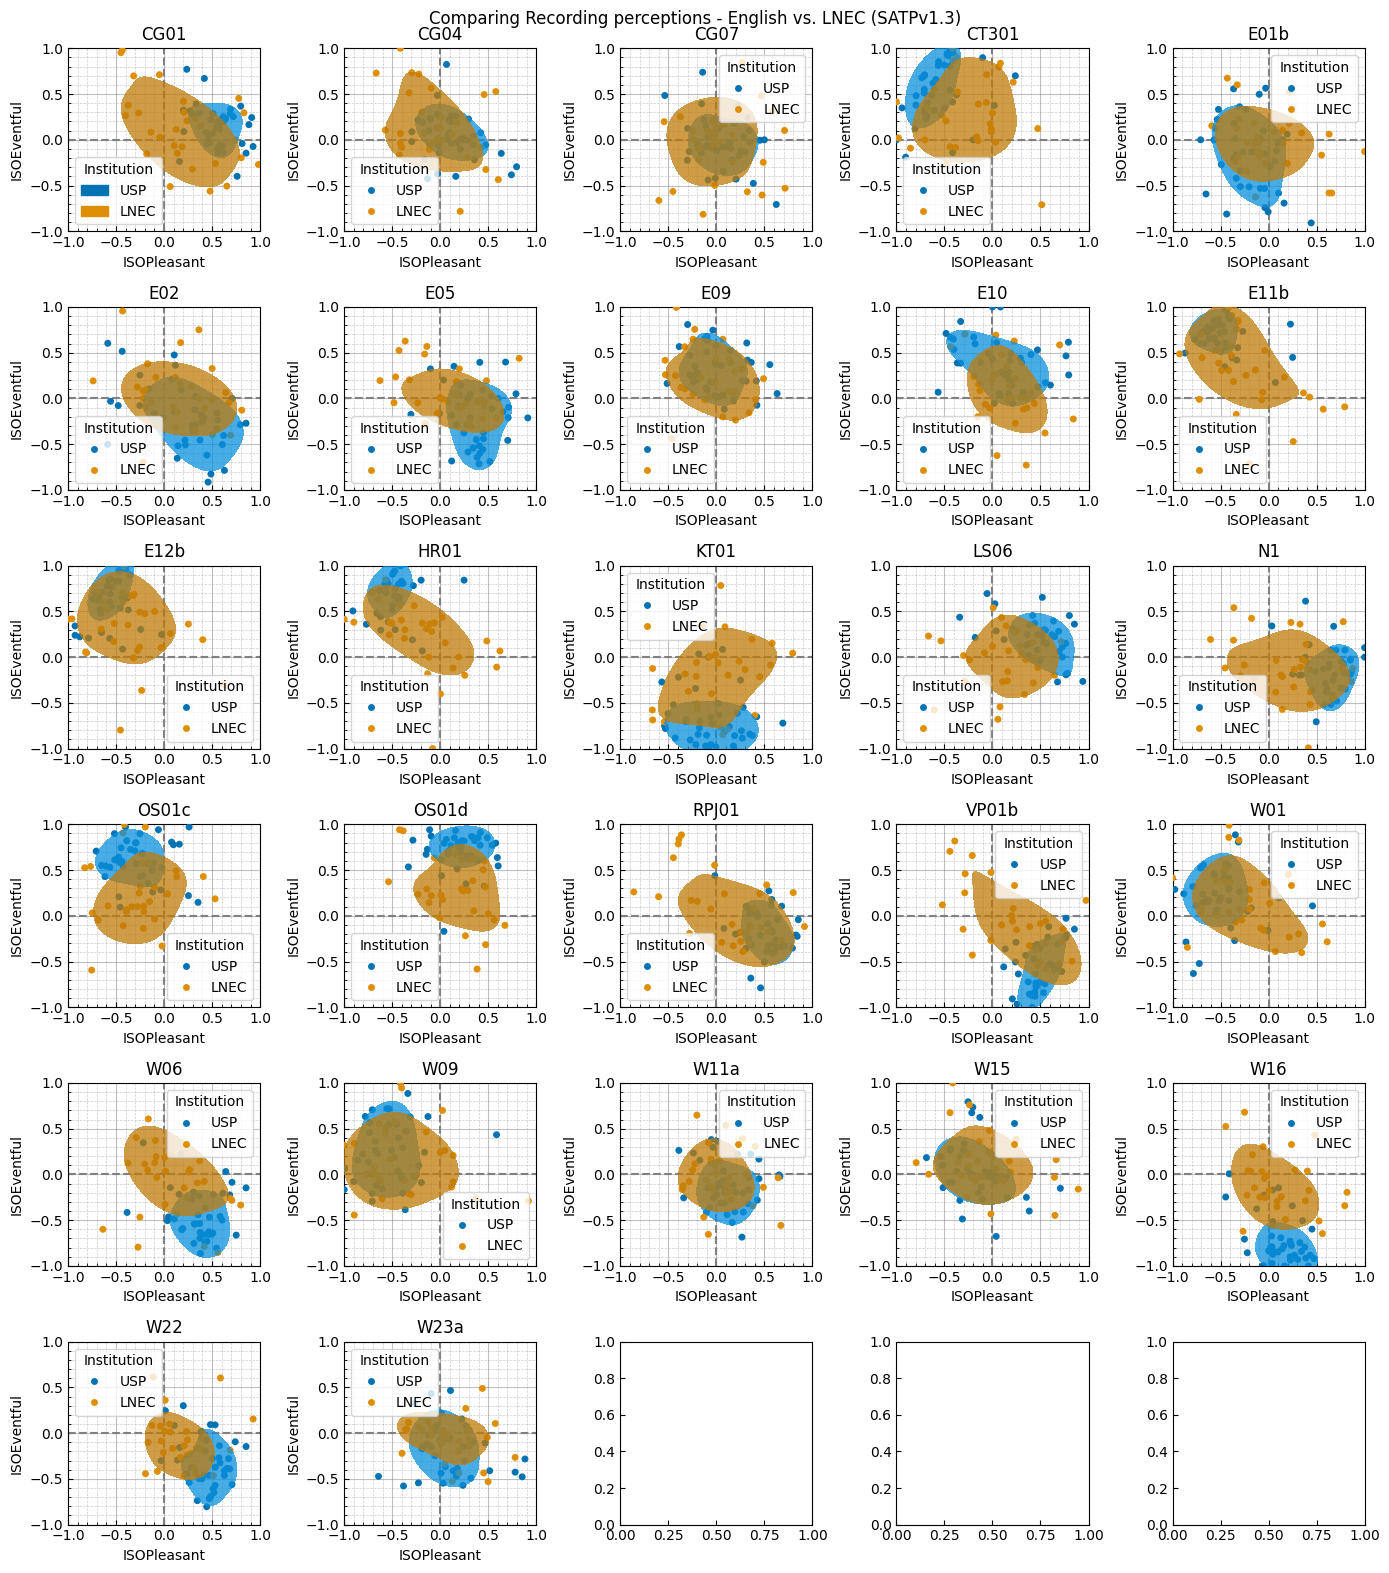

In [ ]:
import numpy as np

fig, axes = plt.subplots(6, 5, figsize=(14, 16))

lang = df.query("Institution in ['USP', @new_inst]")
hue_order = ["USP", new_inst]

for i, recording in enumerate(np.sort(lang.Recording.unique())):
    legend = True if i == 0 else False
    sspy.plotting.density(
        lang.query("Recording == @recording"),
        ax=axes.flatten()[i],
        legend=legend,
        title=f"{recording}",
        hue_order=hue_order,
        alpha=0.75,
        s=20,
        prim_labels=False,
        incl_scatter=True,
        thresh=0.5,
        levels=2,
        hue="Institution",
        palette="colorblind",
    )

fig.suptitle(f"Comparing Recording perceptions - English vs. {new_inst} ({version})")
plt.tight_layout()


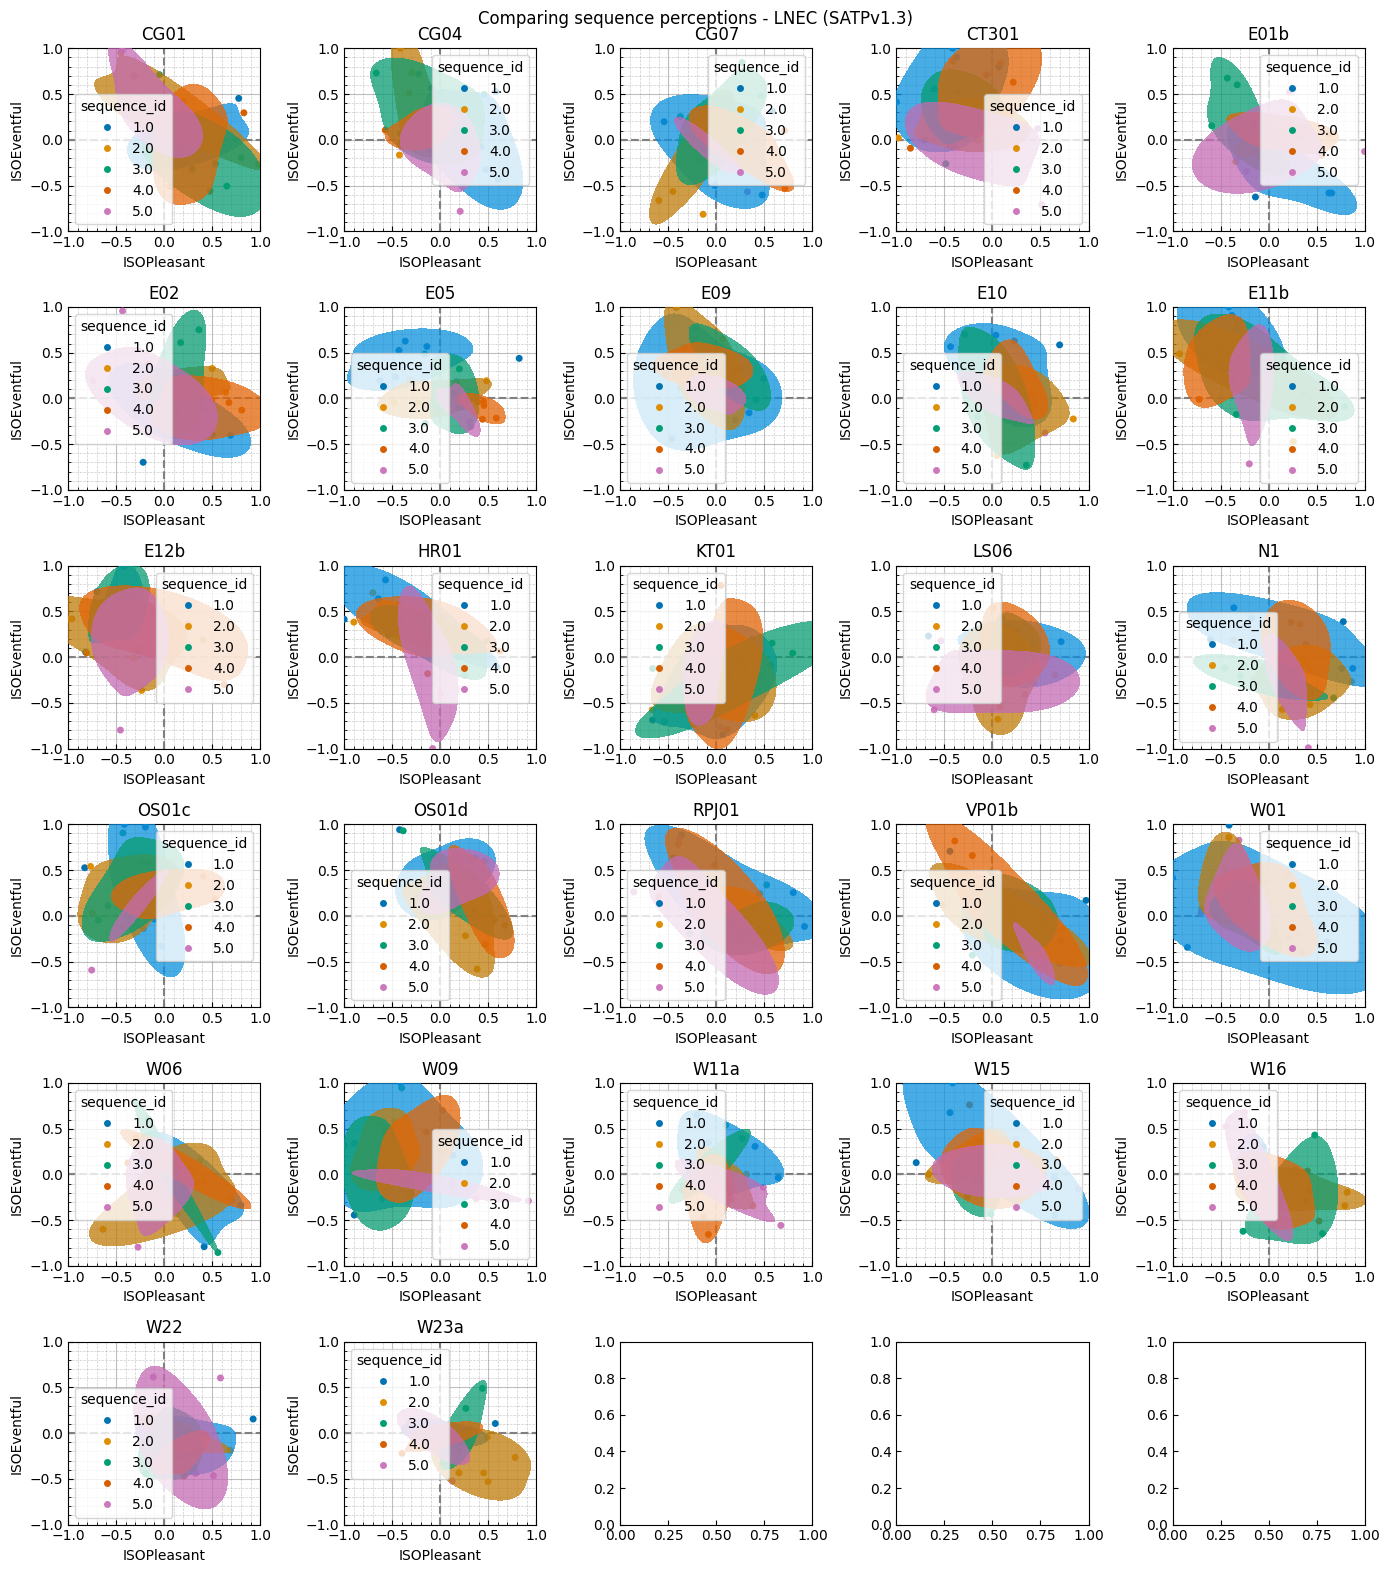

In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(14,16))

lang = df.query("Institution == @new_inst")
hue_order=[1,2,3,4,5]

for i, recording in enumerate(np.sort(lang.Recording.unique())):
    sspy.plotting.density(lang.query("Recording == @recording"), ax=axes.flatten()[i], title=f"{recording}", hue_order=hue_order, alpha=0.75, s=20, prim_labels=False, incl_scatter=True, thresh=0.5, levels=2, hue='sequence_id', palette='colorblind')

fig.suptitle(f"Comparing sequence perceptions - {new_inst} ({version})")
plt.tight_layout()

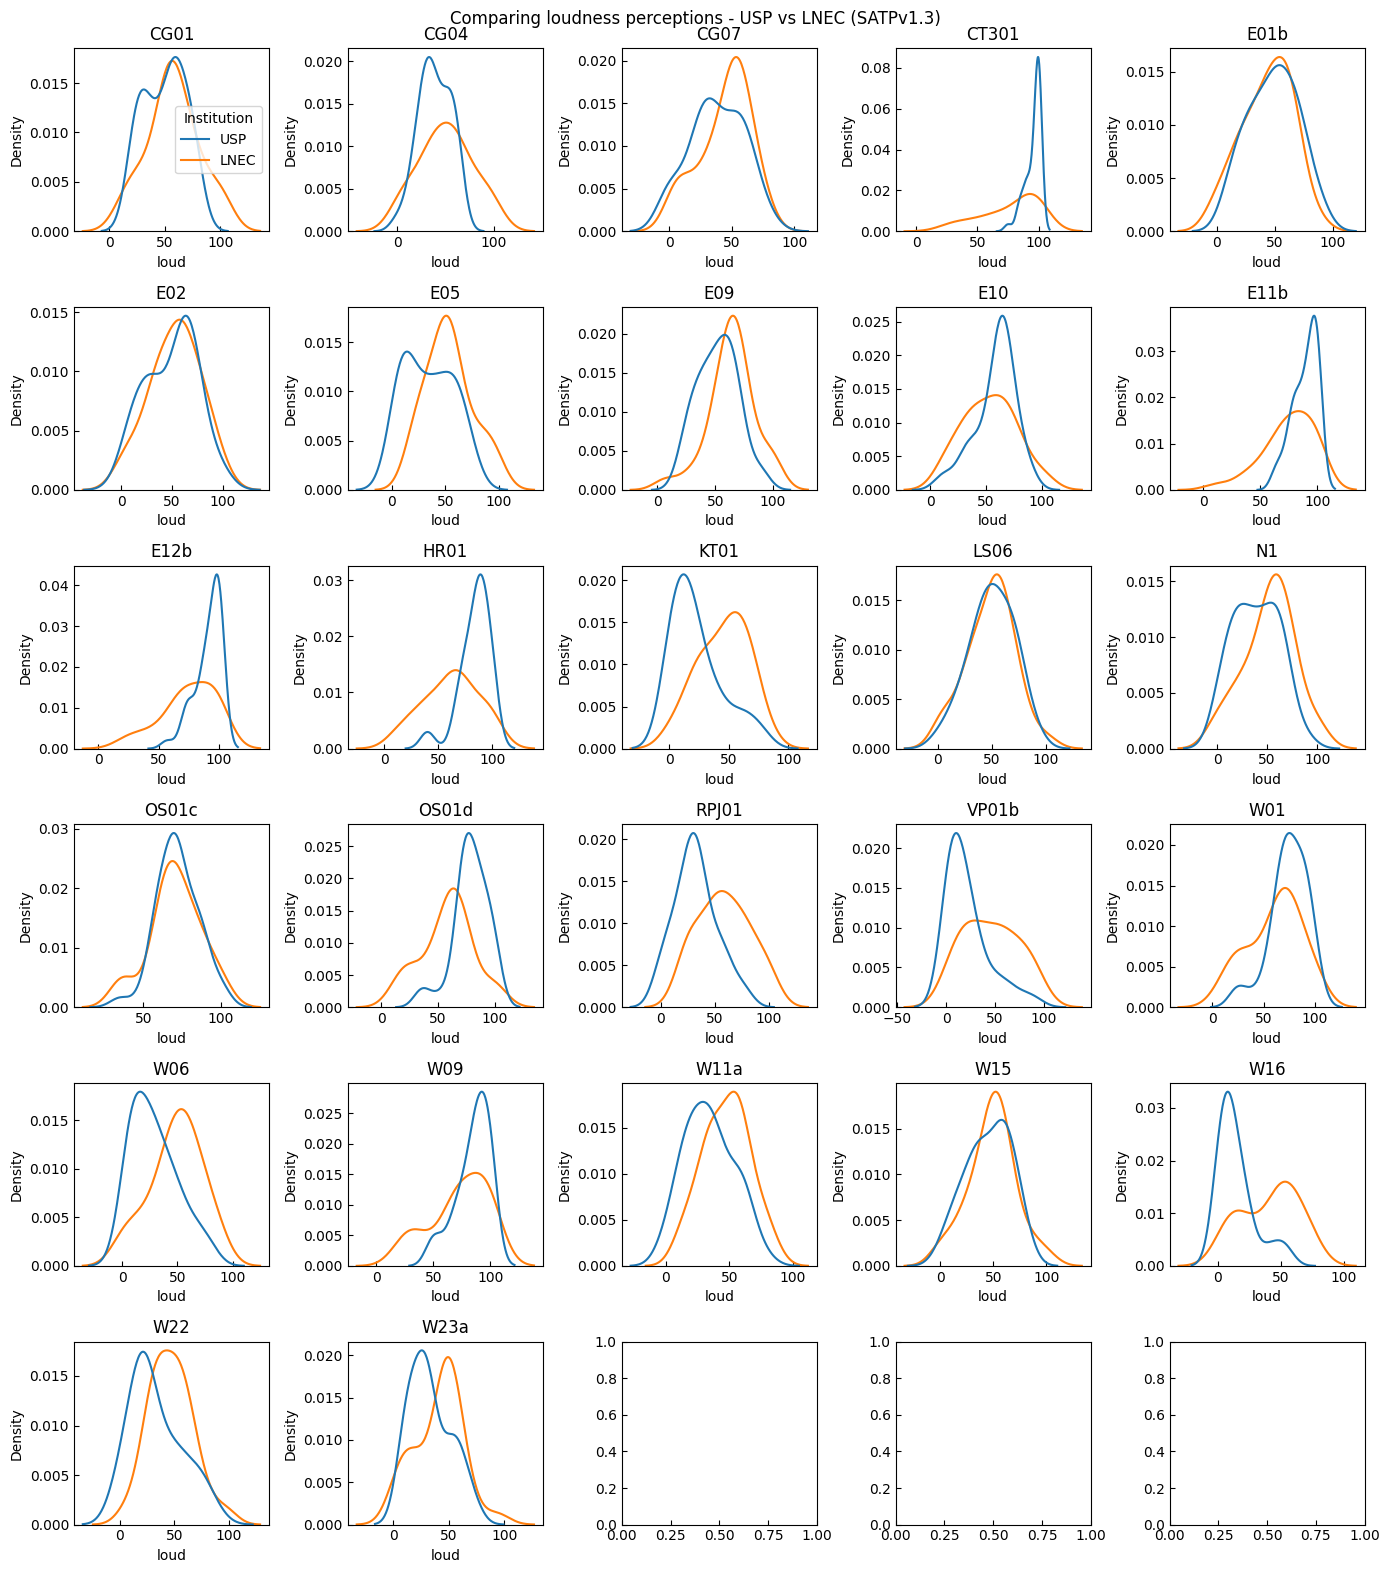

In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(14,16))

lang = df.query("Institution in ['USP', @new_inst]")

hue_order=['USP', new_inst]
for i, recording in enumerate(np.sort(lang.Recording.unique())):
    legend = True if i == 0 else False
    sns.kdeplot(data = lang.query("Recording == @recording"),
    ax = axes.flatten()[i], common_norm=False,
    x='loud', hue='Institution', hue_order=hue_order,
    legend=legend)

    axes.flatten()[i].set_title(recording)

fig.suptitle(f"Comparing loudness perceptions - USP vs {new_inst} ({version})")
plt.tight_layout()

## Standard Deviation comparisons

Since we have many (30+) responses to each sound, I can calculate the degree of variation of responses to the same sound. Essentially, how much do we expect people's responses to vary even when listening to the same sound. To do this, I calculate the standard deviation across the whole dataset (non-Arabic) for each sound, then average this together to get the mean standard deviation for a sound. Then I do the same for the Arabic dataset to see if it matches what we expect.

In [ ]:
def sound_stds(df, paq, verbose=True):
    stds = []
    for sound in df.Recording.unique():
        stds.append(df.query("Recording == @sound")[paq].std())
    avg_std = round(np.mean(stds), 3)
    if verbose:
        print(f"Std in {paq}: ", avg_std)
    return avg_std

In [ ]:
print("Previous Institutions dataset: ")
sound_stds(df.query("Institution != @new_inst"), "ISOPleasant")
sound_stds(df.query("Institution != @new_inst"), "ISOEventful")
sound_stds(df.query("Institution != @new_inst"), "loud")
for paq in isd.PAQ_IDS:
    sound_stds(df.query("Language != @new_inst"), paq)

print(f"\n{new_inst} Institution dataset: ")
sound_stds(df.query("Institution == @new_inst"), "ISOPleasant")
sound_stds(df.query("Institution == @new_inst"), "ISOEventful")
sound_stds(df.query("Institution == @new_inst"), "loud")
for paq in isd.PAQ_IDS:
    sound_stds(df.query("Institution == @new_inst"), paq)

Previous Institutions dataset: 
Std in ISOPleasant:  0.278
Std in ISOEventful:  0.305
Std in loud:  16.904
Std in PAQ1:  21.573
Std in PAQ2:  25.261
Std in PAQ3:  24.796
Std in PAQ4:  24.744
Std in PAQ5:  23.526
Std in PAQ6:  26.764
Std in PAQ7:  26.801
Std in PAQ8:  22.395

LNEC Institution dataset: 
Std in ISOPleasant:  0.358
Std in ISOEventful:  0.346
Std in loud:  22.782
Std in PAQ1:  26.88
Std in PAQ2:  25.606
Std in PAQ3:  25.247
Std in PAQ4:  26.961
Std in PAQ5:  28.914
Std in PAQ6:  28.646
Std in PAQ7:  26.752
Std in PAQ8:  26.728


In [ ]:
import truncated_normal

def trunc_mean(x, a=-1, b=1):
    if type(x) is pd.DataFrame or type(x) is pd.Series:
        x = x.values
    mu = np.mean(x)
    sigma = np.std(x)
    return truncated_normal.truncated_normal_ab_mean(mu, sigma, a, b)
def trunc_std(x, a=-1, b=1):
    if type(x) is pd.DataFrame or type(x) is pd.Series:
        x = x.values
    mu = np.mean(x)
    sigma = np.std(x)
    return np.sqrt(truncated_normal.truncated_normal_ab_variance(mu, sigma, a, b))



for i, recording in enumerate(df.Recording.unique()):
    sound = df.query("Recording == @recording and Language in ['eng', 'ita', 'swe', 'deu', 'ell']")
    print(f"\n{recording}")
    print(f"normal mu    : {round(np.mean(sound.ISOPleasant), 5)}")
    print(f"normal sigma : {round(np.std(sound.ISOPleasant), 5)}")
    print(f"trunc  mu    : {round(trunc_mean(sound.ISOPleasant), 5)}")
    print(f"trunc  sigma : {round(trunc_std(sound.ISOPleasant), 5)}")


CG01
normal mu    : 0.45494
normal sigma : 0.23525
trunc  mu    : 0.44846
trunc  sigma : 0.22754

CG04
normal mu    : 0.13389
normal sigma : 0.24317
trunc  mu    : 0.13372
trunc  sigma : 0.24286

CG07
normal mu    : 0.09711
normal sigma : 0.26299
trunc  mu    : 0.09684
trunc  sigma : 0.26245

CT301
normal mu    : -0.62023
normal sigma : 0.22814
trunc  mu    : -0.59631
trunc  sigma : 0.20589

E01b
normal mu    : -0.227
normal sigma : 0.26705
trunc  mu    : -0.22538
trunc  sigma : 0.26469

E02
normal mu    : 0.16981
normal sigma : 0.30078
trunc  mu    : 0.16721
trunc  sigma : 0.29695

E05
normal mu    : 0.41573
normal sigma : 0.2308
trunc  mu    : 0.41197
trunc  sigma : 0.22596

E09
normal mu    : 0.04346
normal sigma : 0.23628
trunc  mu    : 0.04344
trunc  sigma : 0.23621

E10
normal mu    : 0.03797
normal sigma : 0.25107
trunc  mu    : 0.03793
trunc  sigma : 0.2509

E11b
normal mu    : -0.47014
normal sigma : 0.20815
trunc  mu    : -0.46687
trunc  sigma : 0.20392

E12b
normal mu    : 

In [ ]:
val_lang = df.query("Language in ['eng', 'deu', 'ell', 'swe', 'ita']")
grouped = val_lang.groupby('Recording').mean()[['ISOPleasant', 'ISOEventful']]
grouped[['ISOPleasant_std', 'ISOEventful_std']] = val_lang.groupby('Recording').std()[['ISOPleasant', 'ISOEventful']]
for i, recording in enumerate(grouped.index.unique()):
    x = val_lang.query("Recording == @recording").ISOPleasant
    grouped.loc[recording, 'ISOPleasant_trunc_mean'] = trunc_mean(x)
    grouped.loc[recording, 'ISOPleasant_trunc_std'] = trunc_std(x)
    x = val_lang.query("Recording == @recording").ISOEventful
    grouped.loc[recording, 'ISOEventful_trunc_mean'] = trunc_mean(x)
    grouped.loc[recording, 'ISOEventful_trunc_std'] = trunc_std(x)



TypeError: agg function failed [how->mean,dtype->object]

val_lang.groupby("Recording").trunc_


In [ ]:
grouped

,ISOPleasant,ISOEventful,ISOPleasant_std,ISOEventful_std,ISOPleasant_trunc_mean,ISOPleasant_trunc_std,ISOEventful_trunc_mean,ISOEventful_trunc_std
Recording,,,,,,,,
CG01,0.454413,0.172671,0.237483,0.274148,0.447710,0.228763,0.171566,0.271542
CG04,0.132126,0.009233,0.244725,0.259296,0.131954,0.243620,0.009217,0.258233
CG07,0.098371,0.018841,0.265300,0.276393,0.098074,0.263865,0.018765,0.274937
CT301,-0.618193,0.062696,0.229059,0.316226,-0.594576,0.206287,0.061611,0.312215
E01b,-0.223858,-0.427647,0.265488,0.257528,-0.222427,0.262511,-0.419010,0.246727
E02,0.174540,-0.306660,0.295345,0.275101,0.172271,0.291042,-0.302161,0.268422
E05,0.414536,-0.026705,0.232452,0.286260,0.410717,0.226793,-0.026542,0.284439
E09,0.042939,0.306307,0.237687,0.263057,0.042917,0.236852,0.303134,0.257955
E10,0.038206,0.333159,0.252605,0.233560,0.038159,0.251616,0.331620,0.230586


In [ ]:
grouped[['ISOPleasant', 'ISOPleasant_trunc_mean', 'ISOPleasant_std', 'ISOPleasant_trunc_std']]

,ISOPleasant,ISOPleasant_trunc_mean,ISOPleasant_std,ISOPleasant_trunc_std
Recording,,,,
CG01,0.454413,0.447710,0.237483,0.228763
CG04,0.132126,0.131954,0.244725,0.243620
CG07,0.098371,0.098074,0.265300,0.263865
CT301,-0.618193,-0.594576,0.229059,0.206287
E01b,-0.223858,-0.222427,0.265488,0.262511
E02,0.174540,0.172271,0.295345,0.291042
E05,0.414536,0.410717,0.232452,0.226793
E09,0.042939,0.042917,0.237687,0.236852
E10,0.038206,0.038159,0.252605,0.251616


In [ ]:
grouped[['ISOEventful', 'ISOEventful_trunc_mean', 'ISOEventful_std', 'ISOEventful_trunc_std']]

,ISOEventful,ISOEventful_trunc_mean,ISOEventful_std,ISOEventful_trunc_std
Recording,,,,
CG01,0.172671,0.171566,0.274148,0.271542
CG04,0.009233,0.009217,0.259296,0.258233
CG07,0.018841,0.018765,0.276393,0.274937
CT301,0.062696,0.061611,0.316226,0.312215
E01b,-0.427647,-0.419010,0.257528,0.246727
E02,-0.306660,-0.302161,0.275101,0.268422
E05,-0.026705,-0.026542,0.286260,0.284439
E09,0.306307,0.303134,0.263057,0.257955
E10,0.333159,0.331620,0.233560,0.230586


In [ ]:
def trunc_norm_pdf(mu, sigma, a=-1, b=1, n=100):
    x = []
    y = []
    for i in np.linspace(a, b, n):
        x.append(i)
        y.append(truncated_normal.truncated_normal_ab_pdf(i, mu, sigma, a, b))
    return np.array((x, y))

In [ ]:
ls06_pl = trunc_norm_pdf(grouped.loc['LS06', 'ISOPleasant_trunc_mean'], grouped.loc['LS06', 'ISOPleasant_trunc_std'])
ls06_ev = trunc_norm_pdf(grouped.loc['LS06', 'ISOEventful_trunc_mean'], grouped.loc['LS06', 'ISOEventful_trunc_std'])
ls06 = pd.DataFrame(ls06_pl).T
ls06 = ls06.rename_columns({0: 'x', 1: 'ISOPleasant'})
ls06['ISOEventful'] = ls06_ev[1]


In [ ]:
ls06

,x,ISOPleasant,ISOEventful
0,-1.000000,0.000002,7.736814e-07
1,-0.979798,0.000003,1.249771e-06
2,-0.959596,0.000004,2.002770e-06
3,-0.939394,0.000006,3.183929e-06
4,-0.919192,0.000009,5.021433e-06
...,...,...,...
95,0.919192,0.199130,1.546409e-02
96,0.939394,0.170303,1.169851e-02
97,0.959596,0.144807,8.779469e-03
98,0.979798,0.122417,6.536393e-03
